# 02 — Data Integration & Feature Engineering
**Goal:** Join all four files into one clean training table.  
One row per customer. Every feature. One label.

### What this notebook builds
| Step | Output |
|------|--------|
| 1–4  | Prove year offset & call alignment |
| 5–6  | Coverage analysis |
| 7–11 | Aggregate each behavioural file |
| 12–16| Build billing derived features |
| 17–19| Cross-file composite features |
| 20   | Full join → training table |
| 21–22| Label construction |
| 23–26| Quality checks & diagnostics |
| 27   | Save final tables |

> **Golden rule:** Start from billings (backbone). LEFT JOIN everything else.  
> Never INNER JOIN — missing = no contact = 0, which is itself a signal.


## Cell 1 — Setup & Load

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── path setup ──────────────────────────────────────────────────────────────
import sys
sys.path.append(str(Path.cwd().parents[1]))   # project root on path
from src.data.loader import load_all
from src.data.cleaner import (clean_billings, clean_cc_calls,
                               clean_emails, clean_renewal_calls)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

PROCESSED = Path.cwd().parents[1] / "data" / "processed"
FEATURES  = Path.cwd().parents[1] / "data" / "features"
PROCESSED.mkdir(parents=True, exist_ok=True)
FEATURES.mkdir(parents=True, exist_ok=True)

# ── load & clean ─────────────────────────────────────────────────────────────
raw = load_all()
bills    = clean_billings(raw["billings"])
cc       = clean_cc_calls(raw["cc_calls"])
# emails   = clean_emails(raw["emails"])
rc       = clean_renewal_calls(raw["renewal_calls"])

print("=== Shapes after cleaning ===")
for name, df in [("billings", bills), ("cc_calls", cc),
                  ("renewal_calls", rc)]:
    print(f"  {name:<16} {df.shape}")


=== Shapes after cleaning ===
  billings         (122082, 59)
  cc_calls         (32882, 34)
  renewal_calls    (186534, 41)


## Cell 2 — Prove the Email Year Offset
> **Hypothesis:** `emails.year = Renewal_Year + 1`  
> Prove it from actual data before assuming it.


In [32]:
# Take 2024 Won customers
# won_2024 = bills[(bills["Renewal_Year"] == 2024) &
#                  (bills["Prospect_Outcome"] == "Won")]["Co_Ref"]

# # Look them up in emails
# sample_ids = won_2024.sample(20, random_state=42)
# email_years = (emails[emails["Co_Ref"].isin(sample_ids)]
#                .groupby("Co_Ref")["year"]
#                .unique()
#                .reset_index())

# print("=== Email years for 2024 Won customers (sample of 20) ===")
# print(email_years.to_string())

# print()
# # Full distribution
# all_email_years = emails[emails["Co_Ref"].isin(won_2024)]["year"].value_counts().sort_index()
# print("=== Email year distribution for ALL 2024 Won customers ===")
# print(all_email_years)
# print()
# print("CONFIRMED OFFSET:" if all_email_years.index.tolist() != [2024] else "UNEXPECTED — investigate!")


## Cell 3 — Prove Call Year Alignment
> **Hypothesis:** `cc_calls.Call_Year` and `renewal_calls.Call_Year` match `Renewal_Year` directly (no offset).


In [33]:
sample_ids = won_2024.sample(20, random_state=42)

cc_years  = cc[cc["Co_Ref"].isin(sample_ids)]["Call_Year"].value_counts().sort_index()
rc_years  = rc[rc["Co_Ref"].isin(sample_ids)]["Call_Year"].value_counts().sort_index()

print("=== cc_calls Call_Year for 2024 Won customers ===")
print(cc_years)
print()
print("=== renewal_calls Call_Year for 2024 Won customers ===")
print(rc_years)
print()
print("Calls are in SAME year as Renewal_Year (no offset) — confirmed:", 
      2024 in cc_years.index or 2024 in rc_years.index)


=== cc_calls Call_Year for 2024 Won customers ===
Call_Year
2024     4
2025    19
Name: count, dtype: Int64

=== renewal_calls Call_Year for 2024 Won customers ===
Call_Year
2024    33
2025    45
2026     6
Name: count, dtype: Int64

Calls are in SAME year as Renewal_Year (no offset) — confirmed: True


## Cell 4 — Year Mapping Summary (lock this in)

| File | Year column | Maps to Renewal_Year | Join key |
|------|------------|----------------------|----------|
| billings | Renewal_Year | itself | Co_Ref |
| emails | year | Renewal_Year + 1 | **Co_Ref only** |
| cc_calls | Call_Year | = Renewal_Year | Co_Ref + Call_Year |
| renewal_calls | Call_Year | = Renewal_Year | Co_Ref + Call_Year |

**For emails: always join on Co_Ref only. Never filter by year when joining to training cohort.**


## Cell 5 — Coverage Analysis: How Many Customers Have Behavioural Data?

In [34]:
# Training cohort: 4-week post-renewal window
yr_2024 = bills[bills["Renewal_Year"] == 2024].copy()
yr_2024["_closed_within_4w"] = (
    (yr_2024["Closed_Date"] > yr_2024["Prospect_Renewal_Date"]) &
    (yr_2024["Closed_Date"] <= yr_2024["Prospect_Renewal_Date"] + pd.Timedelta(days=28))
)
train_ids = set(yr_2024[
    (yr_2024["_closed_within_4w"]) &
    (yr_2024["Prospect_Outcome"].isin(["Won", "Churned"]))
]["Co_Ref"])
n_train = len(train_ids)

# Email coverage: SKIPPED (temporal leakage)
cc_ids      = set(cc[(cc["Co_Ref"].isin(train_ids)) & (cc["Call_Year"] == 2024)]["Co_Ref"])
rc_ids      = set(rc[(rc["Co_Ref"].isin(train_ids)) & (rc["Call_Year"] == 2024)]["Co_Ref"])

# coverage stats
both        = cc_ids & rc_ids
none_of     = train_ids - cc_ids - rc_ids

print(f"Training cohort (4-week post-renewal window): {n_train:,} customers")
print(f"  CC calls:       {len(cc_ids):,} ({len(cc_ids)/n_train*100:.1f}%)")
print(f"  Renewal calls:  {len(rc_ids):,} ({len(rc_ids)/n_train*100:.1f}%)")
print(f"  Both:           {len(both):,} ({len(both)/n_train*100:.1f}%)")
print(f"  None:           {len(none_of):,} ({len(none_of)/n_train*100:.1f}%)")
print()
print("Note: Email data excluded (temporal leakage - arrives after renewal decision)")


Training cohort (4-week post-renewal window): 6,686 customers
  CC calls:       536 (8.0%)
  Renewal calls:  4,999 (74.8%)
  Both:           447 (6.7%)
  None:           1,598 (23.9%)

Note: Email data excluded (temporal leakage - arrives after renewal decision)


## Cell 6 — Are Customers Without Behavioural Data Different?
> Zero records ≠ missing data. It means no contact — which is itself a signal.


             File      Group    N  Churn rate %
     Has cc_calls Has record  536         0.900
     Has cc_calls  No record 6150        15.100
Has renewal_calls Has record 4999        14.200
Has renewal_calls  No record 1687        13.400


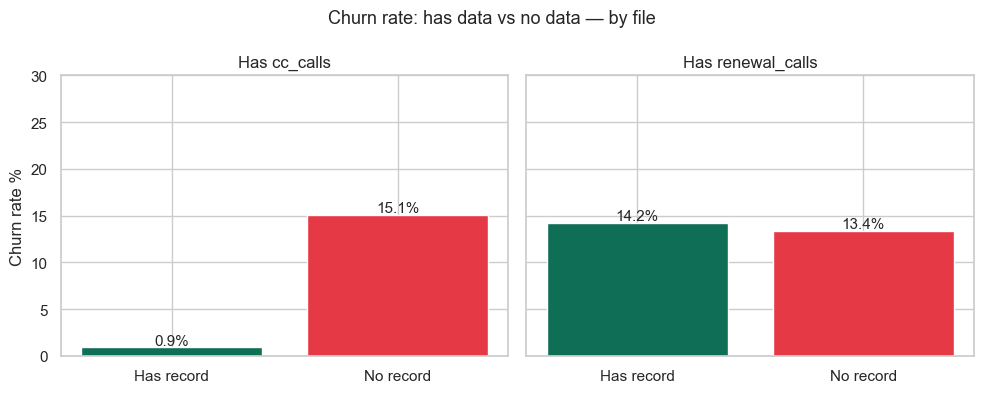

In [35]:
# Build label for 2024 cohort using 4-week post-renewal window
yr_2024 = bills[bills["Renewal_Year"] == 2024].copy()

yr_2024["_closed_within_4w"] = (
    (yr_2024["Closed_Date"] > yr_2024["Prospect_Renewal_Date"]) &
    (yr_2024["Closed_Date"] <= yr_2024["Prospect_Renewal_Date"] + pd.Timedelta(days=28))
)

train_base = yr_2024[
    (yr_2024["_closed_within_4w"]) &
    (yr_2024["Prospect_Outcome"].isin(["Won", "Churned"]))
].copy()

# Create churn label
train_base["churn_label"] = (train_base["Prospect_Outcome"] == "Churned").astype(int)

# Feature flags (only cc_calls and renewal_calls)
train_base["has_cc"] = train_base["Co_Ref"].isin(cc_ids).astype(int)
train_base["has_rc"] = train_base["Co_Ref"].isin(rc_ids).astype(int)

# Churn rate by coverage
results = []

for col, label in [("has_cc", "Has cc_calls"), ("has_rc", "Has renewal_calls")]:
    for val, name in [(1, "Has record"), (0, "No record")]:
        subset = train_base[train_base[col] == val]
        results.append({
            "File": label,
            "Group": name,
            "N": len(subset),
            "Churn rate %": round(subset["churn_label"].mean() * 100, 1)
        })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, file_label in zip(axes, ["Has cc_calls", "Has renewal_calls"]):
    sub = res_df[res_df["File"] == file_label]
    ax.bar(sub["Group"], sub["Churn rate %"], color=["#0F6E56", "#E63946"])
    ax.set_title(file_label)
    ax.set_ylabel("Churn rate %" if ax == axes[0] else "")
    ax.set_ylim(0, 30)

    for i, row in sub.iterrows():
        ax.text(i - sub.index[0], row["Churn rate %"] + 0.3,
                f"{row['Churn rate %']}%", ha="center", fontsize=11)

fig.suptitle("Churn rate: has data vs no data — by file", fontsize=13)
plt.tight_layout()
plt.show()

## Cell 7 — Aggregate Emails → One Row per Customer
**Window: `prior_year` only** (Model 4 / post-renewal features)

Features built:
- `ever_suggested_leave` — any email where customer hinted at leaving
- `ever_competitor_mentioned` — any competitor named
- `ever_price_dissatisfied` — complained about renewal price
- `ever_complained` — general complaint flag
- `ever_financial_hardship` — mentioned financial difficulty
- `ever_refund_mentioned` — refund request in any email
- `ever_membership_overdue` — overdue status flagged
- `ever_negative_experience` — negative experience flag
- `pct_negative_sentiment` — ratio of negative emails
- `avg_sentiment_score` — mean numeric sentiment score
- `min_sentiment_score` — worst single email score (catches outliers)
- `email_count` — total emails in window
- `agent_chase_count_total` — how many times agent had to chase
- `pct_not_engaged` — ratio of emails where customer did not engage


In [36]:
# Email features SKIPPED -- temporal leakage for post-renewal use case.
# emails.year = Renewal_Year + 1, so email data arrives AFTER the renewal decision.
print("Email features: SKIPPED (temporal leakage -- data arrives after renewal decision)")


Email features: SKIPPED (temporal leakage -- data arrives after renewal decision)


## Cell 8 — Aggregate CC Calls → One Row per Customer

Features built:
- `cc_call_count` — total support calls made
- `cc_ever_suggest_leave` — threatened to leave on a support call
- `cc_ever_hardship` — mentioned financial hardship
- `cc_ever_complained` — formal complaint raised
- `cc_ever_platform_issues` — technical friction (platform not working)
- `cc_ever_login_issues` — login problems (disengagement signal)
- `cc_ever_pricing_mentioned` — price came up unprompted on a support call
- `cc_ever_refund_discussed` — refund discussed
- `cc_pct_dissatisfied` — ratio of dissatisfied calls
- `cc_avg_sentiment_delta` — mean of (end_score - start_score): positive = agent helped, negative = agent made it worse
- `cc_min_overall_sentiment` — worst single call overall sentiment


In [37]:
cc_train = cc[(cc["Co_Ref"].isin(train_ids)) & (cc["Call_Year"] == 2024)].copy()

# sentiment delta
cc_train["sentiment_delta"] = (
    pd.to_numeric(cc_train["cc_contractor_sentiment_end_score"], errors="coerce") -
    pd.to_numeric(cc_train["cc_contractor_sentiment_start_score"], errors="coerce")
)
cc_train["overall_score_num"] = pd.to_numeric(
    cc_train["cc_contractor_sentiment_overall_score"], errors="coerce")

cc_feats = cc_train.groupby("Co_Ref").agg(
    cc_call_count           = ("Call_Year",                              "count"),
    cc_ever_suggest_leave   = ("cc_contractor_suggest_leave",            lambda x: int((x=="Yes").any())),
    cc_ever_hardship        = ("cc_business_struggles_financial_hardship",lambda x: int((x=="Yes").any())),
    cc_ever_complained      = ("cc_contractor_complained",               lambda x: int((x=="Yes").any())),
    cc_ever_platform_issues = ("cc_platform_issues",                     lambda x: int((x=="Yes").any())),
    cc_ever_login_issues    = ("cc_login_issues",                        lambda x: int((x=="Yes").any())),
    cc_ever_pricing         = ("cc_pricing_mentioned",                   lambda x: int((x=="Yes").any())),
    cc_ever_refund          = ("cc_refund_discussed",                    lambda x: int((x=="Yes").any())),
    cc_pct_dissatisfied     = ("cc_contractor_sentiment",                lambda x: (x=="Dissatisfied").mean()),
    cc_avg_sentiment_delta  = ("sentiment_delta",                        "mean"),
    cc_min_overall_sentiment= ("overall_score_num",                      "min"),
).reset_index()

print(f"CC call features built: {cc_feats.shape}")
print(f"Customers with cc_calls: {len(cc_feats):,} / {n_train:,} ({len(cc_feats)/n_train*100:.1f}%)")
cc_feats.head(3)


CC call features built: (536, 12)
Customers with cc_calls: 536 / 6,686 (8.0%)


,Co_Ref,cc_call_count,cc_ever_suggest_leave,cc_ever_hardship,cc_ever_complained,cc_ever_platform_issues,cc_ever_login_issues,cc_ever_pricing,cc_ever_refund,cc_pct_dissatisfied,cc_avg_sentiment_delta,cc_min_overall_sentiment
0,AA1392,1,0,0,0,0,0,0,0,0.000,30.000,80.000
1,AA5455,1,0,0,0,0,0,0,0,0.000,30.000,80.000
2,AF3809,2,0,0,0,0,0,0,0,0.000,20.000,80.000


## Cell 9 — Aggregate Renewal Calls → One Row per Customer
**SAFE columns only. Leakage columns never touched.**

Features built:
- `rc_call_count` — total renewal calls needed to close
- `rc_max_call_number` — highest call number reached (friction)
- `rc_discount_requested` — asked for discount/waiver
- `rc_price_increase_discussed` — price increase was raised
- `rc_competitor_mentioned` — named a competitor
- `rc_switching_intent` — explicitly said they might switch
- `rc_rescheduled` — tried to delay/avoid the renewal call
- `rc_agent_flagged_alert` — agent manually escalated this account
- `rc_price_switching_mentioned` — mentioned switching due to price
- `rc_customer_asked_justification` — challenged the price increase


In [38]:
# NEVER use: Membership_Renewal_Decision, Churn_Category, 
#            Desire_To_Cancel, Customer_Renewal_Response_Category
LEAKAGE = ["Membership_Renewal_Decision","Churn_Category",
           "Desire_To_Cancel","Customer_Renewal_Response_Category"]

rc_train = rc[(rc["Co_Ref"].isin(train_ids)) & (rc["Call_Year"] == 2024)].copy()

rc_feats = rc_train.groupby("Co_Ref").agg(
    rc_call_count             = ("Call_Year",                        "count"),
    rc_max_call_number        = ("Call_Number",                      "max"),
    rc_discount_requested     = ("Discount_or_Waiver_Requested",     lambda x: int((x=="Yes").any())),
    rc_price_discussed        = ("Discussion_on_Price_Increase",     lambda x: int((x=="Yes").any())),
    rc_competitor_mentioned   = ("Explicit_Competitor_Mention",      lambda x: int((x=="Yes").any())),
    rc_switching_intent       = ("Explicit_Switching_Intent",        lambda x: int((x=="Yes").any())),
    rc_rescheduled            = ("Call_Reschedule_Request",          lambda x: int((x=="Yes").any())),
    rc_agent_flagged          = ("Agent_Flagged_Membership_Status_Alert", lambda x: int((x=="Yes").any())),
    rc_price_switching        = ("Price_Switching_Mentioned",        lambda x: int((x=="Yes").any())),
    rc_asked_justification    = ("Customer_Asked_For_Justification", lambda x: int((x=="Yes").any())),
).reset_index()

print(f"Renewal call features built: {rc_feats.shape}")
print(f"Customers with renewal_calls: {len(rc_feats):,} / {n_train:,} ({len(rc_feats)/n_train*100:.1f}%)")
rc_feats.head(3)


Renewal call features built: (4999, 11)
Customers with renewal_calls: 4,999 / 6,686 (74.8%)


,Co_Ref,rc_call_count,rc_max_call_number,rc_discount_requested,rc_price_discussed,rc_competitor_mentioned,rc_switching_intent,rc_rescheduled,rc_agent_flagged,rc_price_switching,rc_asked_justification
0,AA1392,7,7,0,0,0,0,0,1,0,0
1,AA1394,4,4,0,0,0,0,0,1,0,0
2,AA2716,5,5,0,0,0,0,0,1,0,0


## Cell 10 — Build Billing Derived Features
Raw billing columns are good. But derived features are often more powerful.

Features built:
- `is_first_year` — no last year price = first renewal ever
- `payment_unknown` — UNKNOWN payment method = lapsed setup
- `auto_renewal_off` — turned off auto-renew = reconsidering
- `price_change_pct` — how much did price change vs last year
- `price_increase_flag` — binary: did price go up at all?
- `price_increase_10pct` — price went up >10%
- `band_enc` — Band A-J as ordinal number
- `band_downgraded` — moved to lower band vs last year
- `anchoring_zero` — has zero anchor clients (highest risk)
- `renewal_score_delta` — score change from release to now
- `has_world_pay_token` — payment token on file (active payment setup)
- `payment_timeframe_flag` — filled vs null (null = never paid)
- `tenure_bucket` — 0-1 yr, 2-3 yr, 4-7 yr, 8+ yr


In [39]:
# Get 2024 cohort using 4-week post-renewal window
yr_2024 = bills[bills["Renewal_Year"] == 2024].copy()
yr_2024["_closed_within_4w"] = (
    (yr_2024["Closed_Date"] > yr_2024["Prospect_Renewal_Date"]) &
    (yr_2024["Closed_Date"] <= yr_2024["Prospect_Renewal_Date"] + pd.Timedelta(days=28))
)
train_base = yr_2024[
    (yr_2024["_closed_within_4w"]) &
    (yr_2024["Prospect_Outcome"].isin(["Won", "Churned"]))
].copy()

# -- basic derivations -------------------------------------------------------
train_base["is_first_year"]     = train_base["Last_Total_Net_Paid"].isna().astype(int)
train_base["payment_unknown"]   = train_base["Payment_Method"].str.upper().eq("UNKNOWN").astype(int)
train_base["auto_renewal_off"]  = (~train_base["Current_Auto_Renewal_Flag"].str.strip().str.upper().eq("YES")).astype(int)

# -- price features ----------------------------------------------------------
train_base["price_change_pct"]  = (
    (train_base["Total_Net_Paid"] - train_base["Last_Total_Net_Paid"])
    / train_base["Last_Total_Net_Paid"].replace(0, np.nan)
).fillna(0)
train_base["price_increase_flag"]   = (train_base["price_change_pct"] > 0).astype(int)
train_base["price_increase_10pct"]  = (train_base["price_change_pct"] > 0.10).astype(int)

# -- band features -----------------------------------------------------------
band_order = {b: i for i, b in enumerate(sorted(train_base["Band"].dropna().unique()))}
train_base["band_enc"]        = train_base["Band"].map(band_order).fillna(-1).astype(int)
last_band_enc                 = train_base["Last_Band"].map(band_order)
train_base["band_downgraded"] = (train_base["band_enc"] < last_band_enc).astype(int)

# -- anchoring ---------------------------------------------------------------
train_base["anchoring_zero"] = (train_base["Current_Anchorings"] == 0).astype(int)

# -- renewal score delta -----------------------------------------------------
train_base["renewal_score_delta"] = (
    train_base["Total_Renewal_Score_New"] - train_base["Renewal_Score_At_Release"]
).fillna(0)

# -- payment token -----------------------------------------------------------
train_base["has_world_pay_token"]    = train_base["Current_World_Pay_Token"].notna().astype(int)
train_base["payment_timeframe_flag"] = train_base["Payment_Timeframe"].notna().astype(int)

# -- tenure bucket -----------------------------------------------------------
train_base["tenure_bucket"] = pd.cut(
    train_base["Tenure_Years"],
    bins=[-1, 1, 3, 7, 100],
    labels=["0-1yr","2-3yr","4-7yr","8+yr"]
)

print(f"Training base with derived features: {train_base.shape}")
print(f"  Won:     {(train_base['Prospect_Outcome']=='Won').sum():,}")
print(f"  Churned: {(train_base['Prospect_Outcome']=='Churned').sum():,}")
train_base[["is_first_year","payment_unknown","auto_renewal_off",
            "price_change_pct","price_increase_10pct","band_enc",
            "anchoring_zero","renewal_score_delta"]].describe()


Training base with derived features: (6686, 73)
  Won:     5,751
  Churned: 935


,is_first_year,payment_unknown,auto_renewal_off,price_change_pct,price_increase_10pct,band_enc,anchoring_zero,renewal_score_delta
count,6686.000,6686.000,6686.000,6686.000,6686.000,6686.000,6686.000,6686.000
mean,0.168,0.122,0.074,0.087,0.273,3.029,0.240,15.462
std,0.374,0.327,0.262,0.164,0.446,2.374,0.427,4.396
min,0.000,0.000,0.000,-0.759,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,1.000,0.000,11.500
50%,0.000,0.000,0.000,0.070,0.000,2.000,0.000,17.000
75%,0.000,0.000,0.000,0.119,1.000,4.000,0.000,18.500
max,1.000,1.000,1.000,3.241,1.000,12.000,1.000,24.000


## Cell 11 — Price Change Distribution (key churn driver)

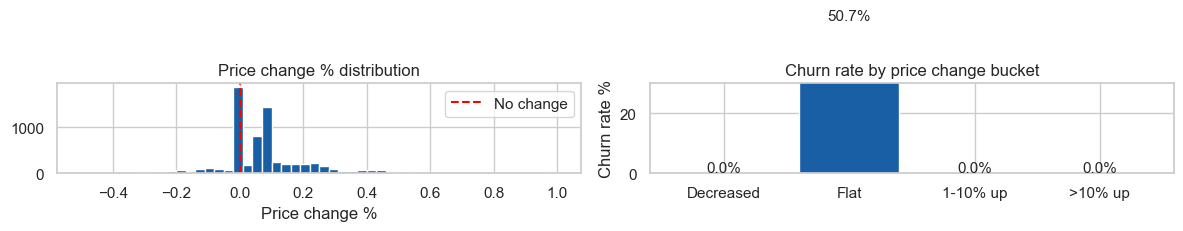

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram of price change %
axes[0].hist(train_base["price_change_pct"].clip(-0.5, 1.0),
             bins=50, color="#185FA5", edgecolor="white")
axes[0].set_title("Price change % distribution")
axes[0].set_xlabel("Price change %")
axes[0].axvline(0, color="red", ls="--", label="No change")
axes[0].legend()

# churn rate by price bucket -- uses 4-week post-renewal label
tb_check = train_base.copy()
tb_check["churn_label"] = (tb_check["Prospect_Outcome"] == "Churned").astype(int)

tb_check["price_bucket"] = pd.cut(
    tb_check["price_change_pct"],
    bins=[-np.inf, -0.01, 0.01, 0.10, np.inf],
    labels=["Decreased","Flat","1-10% up",">10% up"])

churn_by_price = tb_check.groupby("price_bucket", observed=True)["churn_label"].mean() * 100

axes[1].bar(churn_by_price.index.astype(str), churn_by_price.values,
            color=["#0F6E56","#185FA5","#F4A261","#E63946"])
axes[1].set_title("Churn rate by price change bucket")
axes[1].set_ylabel("Churn rate %")
axes[1].set_ylim(0, 30)
for i, v in enumerate(churn_by_price.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()


## Cell 12 — Tenure & Anchoring vs Churn (your two strongest billing signals)

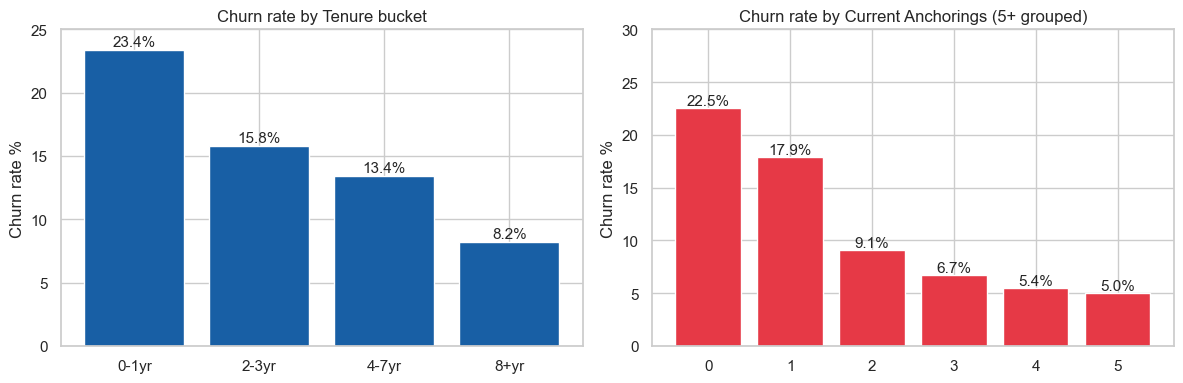

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn by tenure bucket
churn_tenure = tb_check.groupby("tenure_bucket", observed=True)["churn_label"].mean() * 100
axes[0].bar(churn_tenure.index.astype(str), churn_tenure.values, color="#185FA5")
axes[0].set_title("Churn rate by Tenure bucket")
axes[0].set_ylabel("Churn rate %")
axes[0].set_ylim(0, 25)
for i, v in enumerate(churn_tenure.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)

# Churn by anchoring count (capped at 5+)
tb_check["anchoring_capped"] = tb_check["Current_Anchorings"].clip(upper=5)
churn_anch = tb_check.groupby("anchoring_capped")["churn_label"].mean() * 100
axes[1].bar(churn_anch.index.astype(str), churn_anch.values, color="#E63946")
axes[1].set_title("Churn rate by Current Anchorings (5+ grouped)")
axes[1].set_ylabel("Churn rate %")
axes[1].set_ylim(0, 30)
for i, v in enumerate(churn_anch.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()


## Cell 13 — Cross-File Composite Features
These are the most powerful features in the dataset.  
They combine signals from multiple files into a single score.

Features built:
- `any_leave_signal` — suggested leave in ANY file (email OR cc_call OR renewal_call)
- `any_competitor_signal` — competitor mentioned in ANY file
- `any_financial_hardship` — hardship mentioned in email OR cc_call
- `total_negative_flags` — sum of all negative binary flags across all files
- `total_contact_count` — total interactions across all three files
- `has_no_behavioural_data` — zero records in all three files
- `high_friction_score` — many calls + discount request + rescheduled (composite)


In [42]:
# Start with full join (without label yet)
df = train_base.copy()
# email_feats: SKIPPED (temporal leakage)
df = df.merge(cc_feats,    on="Co_Ref", how="left")
df = df.merge(rc_feats,    on="Co_Ref", how="left")

# Fill only numeric columns with 0 (categorical columns like tenure_bucket stay as-is)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)

# -- composite features -------------------------------------------------------
z = pd.Series(0, index=df.index)

df["any_leave_signal"] = (
    (df.get("cc_ever_suggest_leave", z)==1) |
    (df.get("rc_switching_intent", z)==1)
).astype(int)

df["any_competitor_signal"] = (
    (df.get("rc_competitor_mentioned", z)==1)
).astype(int)

df["any_financial_hardship"] = (
    (df.get("cc_ever_hardship", z)==1)
).astype(int)

df["any_complaint"] = (
    (df.get("cc_ever_complained", z)==1)
).astype(int)

neg_flag_cols = [
    "cc_ever_suggest_leave","cc_ever_hardship","cc_ever_complained",
    "cc_ever_platform_issues","cc_ever_pricing","rc_discount_requested",
    "rc_competitor_mentioned","rc_switching_intent","rc_rescheduled","rc_agent_flagged",
    "auto_renewal_off","payment_unknown","anchoring_zero","price_increase_10pct",
]
existing = [c for c in neg_flag_cols if c in df.columns]
df["total_negative_flags"] = df[existing].sum(axis=1)

df["total_contact_count"] = (
    df.get("cc_call_count", z) +
    df.get("rc_call_count", z)
)
df["has_no_behavioural_data"] = (df["total_contact_count"]==0).astype(int)

df["high_friction_score"] = (
    (df.get("rc_max_call_number", z) >= 3).astype(int) +
    (df.get("rc_discount_requested", z)==1).astype(int) +
    (df.get("rc_rescheduled", z)==1).astype(int) +
    (df.get("cc_call_count", z) >= 3).astype(int)
)

df["critical_risk_billing"] = (
    (df.get("auto_renewal_off", z)==1) &
    (df.get("anchoring_zero", z)==1)
).astype(int)

print(f"Full joined table: {df.shape}")
print(f"Duplicate Co_Refs: {df['Co_Ref'].duplicated().sum()} (expected: 0)")


Full joined table: (6686, 103)
Duplicate Co_Refs: 0 (expected: 0)


## Cell 14 — Full Join Quality Check
After joining everything together, verify the table is intact.


In [43]:
print("=== Join integrity checks ===")
print(f"Row count:          {len(df):,}  (expected: {n_train:,})")
print(f"Duplicate Co_Refs:  {df['Co_Ref'].duplicated().sum()}  (expected: 0)")
print(f"Remaining nulls:    {df.isnull().sum().sum()}")
print()

# Null summary for remaining nulls (billing columns — intentional)
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0].sort_values(ascending=False)
if len(remaining_nulls):
    print("Intentional nulls remaining (billing columns):")
    print(remaining_nulls)
else:
    print("No nulls remaining. All good.")


=== Join integrity checks ===
Row count:          6,686  (expected: 6,686)
Duplicate Co_Refs:  0  (expected: 0)
Remaining nulls:    4192

Intentional nulls remaining (billing columns):
Current_Anchor_List           1604
Last_Band                     1125
Last_Renewal                  1121
Tenure_Group                    80
tenure_bucket                   80
Registration_Date               80
Proforma_Date                   18
Proforma_Account_Stage          12
Proforma_Auto_Renewal           12
Proforma_World_Pay_Token        12
Connection_Group                12
Proforma_Membership_Status      12
Proforma_Audit_Status           12
Anchor_Group                    12
dtype: int64


## Cell 15 — Label Construction
**Post-renewal definition (4-week window):**
- `Closed_Date` is within 4 weeks (28 days) after `Prospect_Renewal_Date`
- `Prospect_Outcome = Won` → label = **0** (retained)
- `Prospect_Outcome = Churned` → label = **1** (churned)
- `Prospect_Outcome = Open` → **excluded** (undecided within window)
- Rows outside the 4-week window → **excluded**


=== Post-renewal outcome breakdown (4-week window) ===
outcome_post_renewal
Won        5751
Churned     935
Name: count, dtype: int64

Final churn rate: 13.98%
Churned (label=1): 935
Retained (label=0): 5,751


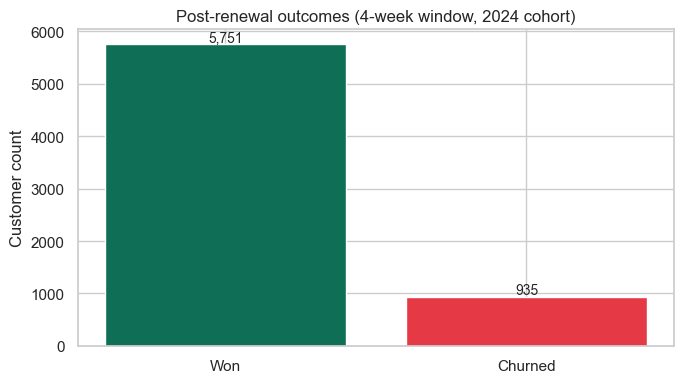

In [44]:
# Apply the 4-week post-renewal window for label construction
yr_data = bills[bills["Renewal_Year"] == 2024].copy()
yr_data["_closed_within_4w"] = (
    (yr_data["Closed_Date"] > yr_data["Prospect_Renewal_Date"]) &
    (yr_data["Closed_Date"] <= yr_data["Prospect_Renewal_Date"] + pd.Timedelta(days=28))
)
label_source = yr_data[
    (yr_data["_closed_within_4w"]) &
    (yr_data["Prospect_Outcome"].isin(["Won", "Churned"]))
][["Co_Ref", "Prospect_Outcome"]].copy()

df = df.merge(label_source.rename(columns={"Prospect_Outcome": "outcome_post_renewal"}),
              on="Co_Ref", how="inner")
df["churn_label"] = (df["outcome_post_renewal"] == "Churned").astype(int)

# breakdown
breakdown = df["outcome_post_renewal"].value_counts()
print("=== Post-renewal outcome breakdown (4-week window) ===")
print(breakdown)
print()
print(f"Final churn rate: {df['churn_label'].mean()*100:.2f}%")
print(f"Churned (label=1): {df['churn_label'].sum():,}")
print(f"Retained (label=0): {(df['churn_label']==0).sum():,}")

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"Won":"#0F6E56","Churned":"#E63946"}
bars = ax.bar(breakdown.index, breakdown.values,
              color=[colors.get(k,"#ccc") for k in breakdown.index])
ax.set_title("Post-renewal outcomes (4-week window, 2024 cohort)")
ax.set_ylabel("Customer count")
for bar, val in zip(bars, breakdown.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50,
            f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## Cell 16 — Label Quality Checks

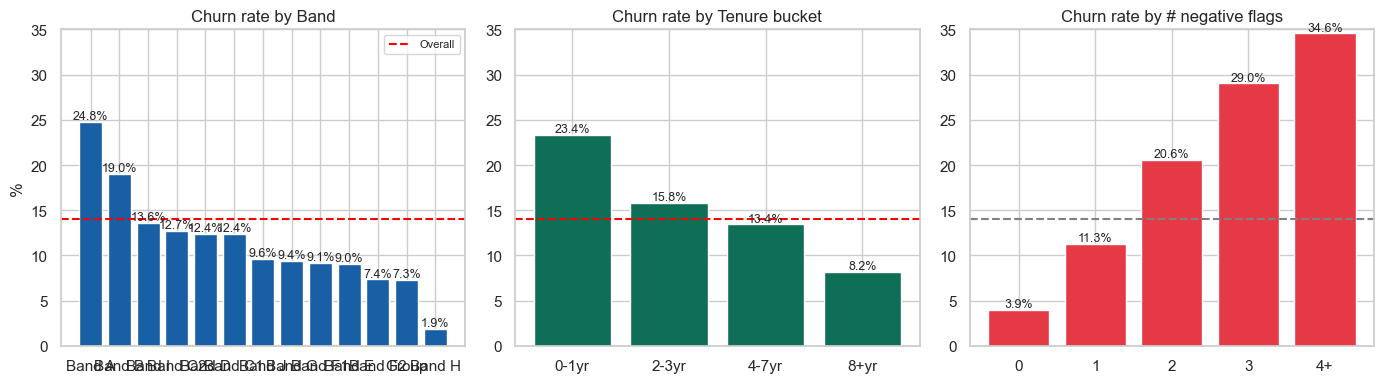

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# churn rate by Band
cr_band = df.groupby("Band")["churn_label"].mean().sort_values(ascending=False) * 100
axes[0].bar(cr_band.index, cr_band.values, color="#185FA5")
axes[0].set_title("Churn rate by Band")
axes[0].set_ylabel("%")
axes[0].axhline(df["churn_label"].mean()*100, color="red", ls="--", label="Overall")
axes[0].legend(fontsize=8)

# churn rate by tenure bucket
cr_ten = df.groupby("tenure_bucket", observed=True)["churn_label"].mean() * 100
axes[1].bar(cr_ten.index.astype(str), cr_ten.values, color="#0F6E56")
axes[1].set_title("Churn rate by Tenure bucket")
axes[1].axhline(df["churn_label"].mean()*100, color="red", ls="--")

# churn rate by total_negative_flags bucket
df["flag_bucket"] = pd.cut(df["total_negative_flags"],
                            bins=[-1,0,1,2,3,100],
                            labels=["0","1","2","3","4+"])
cr_flags = df.groupby("flag_bucket", observed=True)["churn_label"].mean() * 100
axes[2].bar(cr_flags.index.astype(str), cr_flags.values, color="#E63946")
axes[2].set_title("Churn rate by # negative flags")
axes[2].axhline(df["churn_label"].mean()*100, color="grey", ls="--")

for ax in axes:
    ax.set_ylim(0, 35)
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{bar.get_height():.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## Cell 17 — Feature Correlation with Churn Label

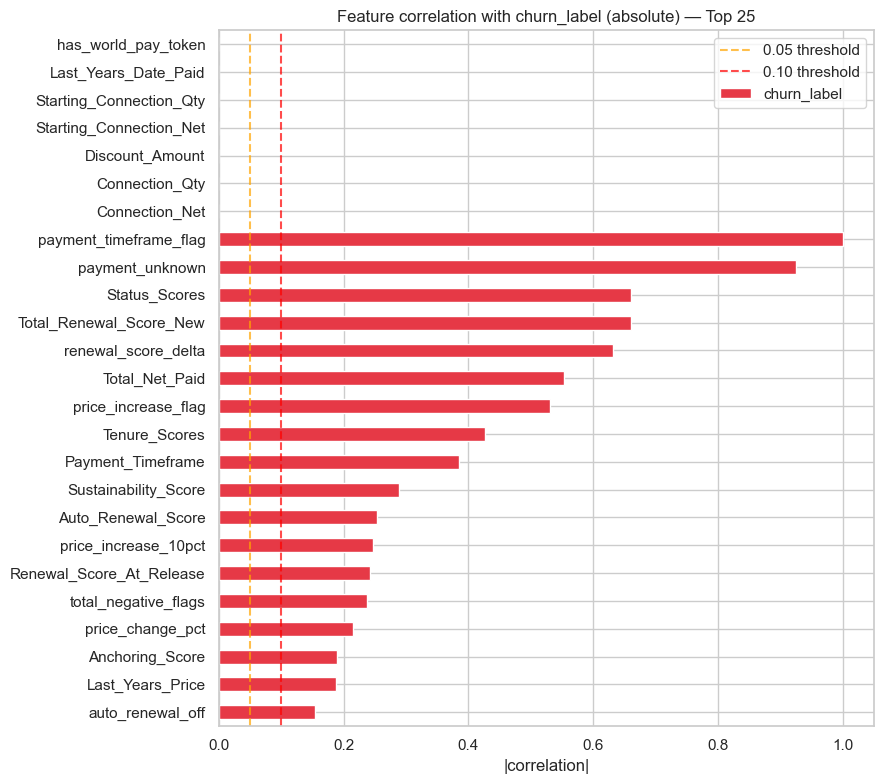

Top 10 most correlated features:
payment_timeframe_flag    1.000
payment_unknown           0.925
Status_Scores             0.661
Connection_Net              NaN
Connection_Qty              NaN
Discount_Amount             NaN
Starting_Connection_Net     NaN
Starting_Connection_Qty     NaN
Last_Years_Date_Paid        NaN
has_world_pay_token         NaN
Name: churn_label, dtype: float64


In [46]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ["churn_label","Renewal_Year","band_enc"]
feature_cols = [c for c in numeric_cols if c not in exclude and c != "Co_Ref"]

correlations = df[feature_cols + ["churn_label"]].corr()["churn_label"].drop("churn_label")
correlations = correlations.abs().sort_values(ascending=True)

# top 25
top25 = correlations.tail(25)
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#E63946" if v > 0.1 else "#185FA5" if v > 0.05 else "#888"
          for v in top25.values]
top25.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature correlation with churn_label (absolute) — Top 25")
ax.set_xlabel("|correlation|")
ax.axvline(0.05, color="orange", ls="--", alpha=0.7, label="0.05 threshold")
ax.axvline(0.10, color="red",    ls="--", alpha=0.7, label="0.10 threshold")
ax.legend()
plt.tight_layout()
plt.show()
print("Top 10 most correlated features:")
print(correlations.tail(10).sort_values(ascending=False).round(4))


## Cell 18 — Composite Feature Power Check

In [47]:
composite_cols = ["any_leave_signal","any_competitor_signal",
                   "any_financial_hardship","total_negative_flags",
                   "has_no_behavioural_data","high_friction_score",
                   "auto_renewal_off","anchoring_zero","price_increase_10pct"]
composite_cols = [c for c in composite_cols if c in df.columns]

results = []
for col in composite_cols:
    for val in sorted(df[col].unique()):
        sub = df[df[col] == val]
        results.append({
            "Feature": col,
            "Value": val,
            "N": len(sub),
            "Churn %": round(sub["churn_label"].mean()*100, 1)
        })

res_df = pd.DataFrame(results)
# pivot for readability
pivot = res_df[res_df["Value"].isin([0,1])].pivot(index="Feature", columns="Value", values="Churn %")
pivot.columns = ["No (0) Churn %","Yes (1) Churn %"]
pivot["Lift"] = (pivot["Yes (1) Churn %"] / pivot["No (0) Churn %"]).round(2)
pivot = pivot.sort_values("Lift", ascending=False)
print(pivot.to_string())


                         No (0) Churn %  Yes (1) Churn %  Lift
Feature                                                       
total_negative_flags              3.900           11.300 2.900
auto_renewal_off                 12.500           32.800 2.620
anchoring_zero                   11.300           22.500 1.990
any_leave_signal                 13.900           25.000 1.800
any_competitor_signal            13.800           19.900 1.440
high_friction_score              12.400           15.200 1.230
has_no_behavioural_data          13.900           14.100 1.010
any_financial_hardship           14.000            4.000 0.290
price_increase_10pct             19.200            0.000 0.000


## Cell 19 -- Build Prediction Cohort (2025 post-renewal window)
Same 4-week post-renewal window pipeline -- just a different base year.
These are the customers you will actually score in production.

Uses billing, CC calls, and renewal calls only (emails excluded).


In [48]:
# 2025 prediction cohort: 4-week post-renewal window
yr_2025 = bills[bills["Renewal_Year"] == 2025].copy()
yr_2025["_closed_within_4w"] = (
    (yr_2025["Closed_Date"] > yr_2025["Prospect_Renewal_Date"]) &
    (yr_2025["Closed_Date"] <= yr_2025["Prospect_Renewal_Date"] + pd.Timedelta(days=28))
)
pred_ids = set(yr_2025[
    (yr_2025["_closed_within_4w"]) &
    (yr_2025["Prospect_Outcome"].isin(["Won", "Churned"]))
]["Co_Ref"])

# CC calls and renewal calls for 2025
pred_cc = cc[(cc["Co_Ref"].isin(pred_ids)) & (cc["Call_Year"] == 2025)].copy()
pred_rc = rc[(rc["Co_Ref"].isin(pred_ids)) & (rc["Call_Year"] == 2025)].copy()

print(f"Prediction pool (4-week window): {len(pred_ids):,} customers")
print(f"  CC call records:        {len(pred_cc):,} ({pred_cc['Co_Ref'].nunique():,} customers)")
print(f"  Renewal call records:   {len(pred_rc):,} ({pred_rc['Co_Ref'].nunique():,} customers)")
print(f"  Email records:          SKIPPED (temporal leakage)")
print()

# Coverage comparison: train vs predict
print("=== Data richness: Train (2024) vs Predict (2025) ===")
comparison = pd.DataFrame({
    "File":          ["CC calls","Renewal calls"],
    "Train (2024)":  [len(cc_feats), len(rc_feats)],
    "Predict (2025)":[pred_cc['Co_Ref'].nunique(), pred_rc['Co_Ref'].nunique()],
})
print(comparison.to_string(index=False))


Prediction pool (4-week window): 6,219 customers
  CC call records:        3,826 (1,903 customers)
  Renewal call records:   27,390 (5,843 customers)
  Email records:          SKIPPED (temporal leakage)

=== Data richness: Train (2024) vs Predict (2025) ===
         File  Train (2024)  Predict (2025)
     CC calls           536            1903
Renewal calls          4999            5843


## Cell 20 — Save Final Tables

In [49]:
# -- drop raw columns not needed in the final table ----------------------------
DROP_COLS = ["Renewal_Year","Prospect_Outcome","outcome_post_renewal",
             "Band","Payment_Method","Current_Auto_Renewal_Flag",
             "Last_Band","tenure_bucket","flag_bucket",
             "Current_Anchor_List","Prospect_Status","Connection_Group",
             "Tenure_Group","Anchor_Group","Proforma_Account_Stage",
             "Proforma_Audit_Status","Proforma_Membership_Status",
             "Proforma_Approved_Lists","DateTime_Out","Last_Years_Date_Paid",
             "Proforma_Date","Closed_Date","Registration_Date",
             "Prospect_Renewal_Date","Renewal_Month","_closed_within_4w",
             # date columns pyarrow struggles with if mixed nulls
             "Last_Renewal"]

train_final = df.copy()

# -- actually apply the drop --------------------------------------------------
train_final = train_final.drop(
    columns=[c for c in DROP_COLS if c in train_final.columns],
    errors="ignore"
)

# -- fix dtypes that break parquet --------------------------------------------
for col in train_final.select_dtypes(include="category").columns:
    train_final[col] = train_final[col].astype(str)

# nullable Int64 -> standard int (fill NaN first)
for col in train_final.select_dtypes(include="Int64").columns:
    train_final[col] = train_final[col].fillna(0).astype(int)

# any remaining object columns with mixed types -> string
for col in train_final.select_dtypes(include="object").columns:
    train_final[col] = train_final[col].astype(str)

# -- save ---------------------------------------------------------------------
train_final.to_parquet(FEATURES / "train_2024.parquet", index=False)

print(f"Saved: train_2024.parquet -- {train_final.shape}")
print(f"  Churned:  {train_final['churn_label'].sum():,} ({train_final['churn_label'].mean()*100:.2f}%)")
print(f"  Retained: {(train_final['churn_label']==0).sum():,}")
print()
print("Feature columns in final table:")
feature_summary = [(c, str(train_final[c].dtype), train_final[c].isnull().sum())
                   for c in train_final.columns if c not in ["Co_Ref","churn_label"]]
feat_df = pd.DataFrame(feature_summary, columns=["Column","dtype","nulls"])
print(feat_df.to_string(index=False))


Saved: train_2024.parquet -- (6686, 79)
  Churned:  935 (13.98%)
  Retained: 5,751

Feature columns in final table:
                  Column   dtype  nulls
          Connection_Net float64      0
          Connection_Qty float64      0
         Discount_Amount float64      0
    Sustainability_Score float64      0
 Total_Renewal_Score_New float64      0
 Starting_Connection_Net float64      0
 Starting_Connection_Qty float64      0
        Last_Years_Price float64      0
      Auto_Renewal_Score   int64      0
           Status_Scores   int64      0
         Anchoring_Score float64      0
           Tenure_Scores float64      0
   Proforma_Auto_Renewal     str     12
Proforma_World_Pay_Token     str     12
      Current_Anchorings   int64      0
       Payment_Timeframe float64      0
 Current_World_Pay_Token     str      0
Renewal_Score_At_Release float64      0
            Tenure_Years float64      0
            Starting_Net   int64      0
            Starting_Vat float64      0
    

C:\Users\Dell\AppData\Local\Temp\ipykernel_19784\2043597032.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train_final.select_dtypes(include="object").columns:


In [50]:
train_final.isnull().sum()

Co_Ref                     0
Connection_Net             0
Connection_Qty             0
Discount_Amount            0
Sustainability_Score       0
                          ..
total_contact_count        0
has_no_behavioural_data    0
high_friction_score        0
critical_risk_billing      0
churn_label                0
Length: 79, dtype: int64

## Cell 21 -- Key Findings Summary

Fill this in after running all cells above.

### Post-renewal definition
- Cohort: `Closed_Date` within 4 weeks (28 days) after `Prospect_Renewal_Date`
- Label: `Prospect_Outcome = Churned` -> 1, `Won` -> 0
- Email data excluded (temporal leakage -- arrives after renewal decision)

### Year mapping -- confirmed
- `cc_calls.Call_Year = Renewal_Year` -- same year
- `renewal_calls.Call_Year = Renewal_Year` -- same year
- `emails.year = Renewal_Year + 1` -- NOT USED (temporal leakage)

### Coverage (fill in actual numbers)
| File | Customers covered | % of training set |
|------|-------------------|------------------|
| cc_calls | -- | -- |
| renewal_calls | -- | -- |
| Both | -- | -- |
| None (billing only) | -- | -- |

### Final training table
- Shape: -- rows x -- columns
- Churn rate: --%
- Scale_pos_weight to use in XGBoost: --

### Top 5 most correlated features with churn
1. --
2. --
3. --
4. --
5. --

### Data quality issues found
- --

### Surprises
- --
